# Analysis of Barista Agent Runs

This notebook analyzes 175 workflow runs (35 Java classes x 5 runs) from Barista, an AI agent system that synthesizes typestate specifications. We examine how specification complexity affects agent cost, duration, tool usage, and reproducibility.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scikit_posthocs as sp
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
COMPLEXITY_ORDER = ["none", "simple", "moderate", "complex"]
COMPLEXITY_COLORS = {"none": "#999999", "simple": "#4daf4a", "moderate": "#ff7f00", "complex": "#e41a1c"}

# Load metrics
df_raw = pd.read_csv("agent_metrics.csv")

# Fix known typo in folder name: dragsoucecontext -> dragsourcecontext
df_raw["class_name"] = df_raw["class_name"].replace({"dragsoucecontext": "dragsourcecontext"})

# Load complexity ratings
comp = pd.read_csv(
    "manual/complexity/complexity_review_final.csv",
    skiprows=4,  # skip instruction rows
    usecols=["Class", "Final_Complexity"],
)
comp.columns = ["java_class", "complexity"]
comp["class_name"] = comp["java_class"].str.split(".").str[-1].str.lower()
comp["complexity"] = comp["complexity"].str.strip().str.lower()

# Merge
df_raw = df_raw.merge(comp[["class_name", "complexity"]], on="class_name", how="left")
assert df_raw["complexity"].notna().all(), f"Unmatched classes: {df_raw[df_raw['complexity'].isna()]['class_name'].unique()}"

# Flag and filter failed runs (cost=0, sdk_turns=0 — likely incomplete)
failed = df_raw[(df_raw["total_cost_usd"] == 0) & (df_raw["sdk_turns"] == 0)]
print(f"Flagged {len(failed)} likely failed runs (cost=0, sdk_turns=0):")
print(failed[["class_name", "run", "total_cost_usd", "wall_clock_secs", "sdk_turns"]].to_string(index=False))

df = df_raw[~((df_raw["total_cost_usd"] == 0) & (df_raw["sdk_turns"] == 0))].copy()
df["complexity"] = pd.Categorical(df["complexity"], categories=COMPLEXITY_ORDER, ordered=True)

# MCP tool columns
mcp_cols = [c for c in df.columns if c.startswith("tool_mcp_")]
df["total_mcp_calls"] = df[mcp_cols].sum(axis=1)

print(f"\nUsing {len(df)} runs across {df['class_name'].nunique()} classes (excluded {len(failed)} failed)")
print(f"\nComplexity distribution (classes):")
print(comp["complexity"].value_counts().reindex(COMPLEXITY_ORDER))

Flagged 7 likely failed runs (cost=0, sdk_turns=0):
       class_name  run  total_cost_usd  wall_clock_secs  sdk_turns
   choicecallback    1             0.0          1080.68          0
   choicecallback    4             0.0          1082.18          0
  imagewriteparam    4             0.0          1174.23          0
pipedoutputstream    1             0.0             0.00          0
      pipedwriter    4             0.0          1084.68          0
  zipoutputstream    2             0.0          1235.55          0
  zipoutputstream    4             0.0          1082.40          0

Using 168 runs across 35 classes (excluded 7 failed)

Complexity distribution (classes):
complexity
none         6
simple       9
moderate     7
complex     13
Name: count, dtype: int64


## 1. Overview

Summary statistics across all 175 runs.

In [2]:
summary_cols = ["wall_clock_secs", "total_cost_usd", "sdk_turns", "total_tool_calls", "total_mcp_calls", "total_turns", "total_tool_errors"]
summary = df[summary_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
summary.columns = ["Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]
summary.index = ["Duration (s)", "Cost (USD)", "SDK Turns", "Tool Calls", "MCP Calls", "Agent Turns", "Tool Errors"]
summary.round(2)

,Mean,Std,Min,Q1,Median,Q3,Max
Duration (s),410.49,250.00,25.62,261.30,393.49,574.36,1069.38
Cost (USD),2.27,1.69,0.16,1.29,1.91,3.04,8.59
SDK Turns,4.11,1.87,1.00,2.00,5.00,6.00,8.00
Tool Calls,69.26,62.34,2.00,17.75,58.00,99.25,285.00
MCP Calls,4.74,3.39,0.00,3.00,5.00,6.00,23.00
Agent Turns,76.10,62.88,4.00,26.75,65.00,106.25,295.00
Tool Errors,0.96,1.36,0.00,0.00,0.00,1.25,7.00


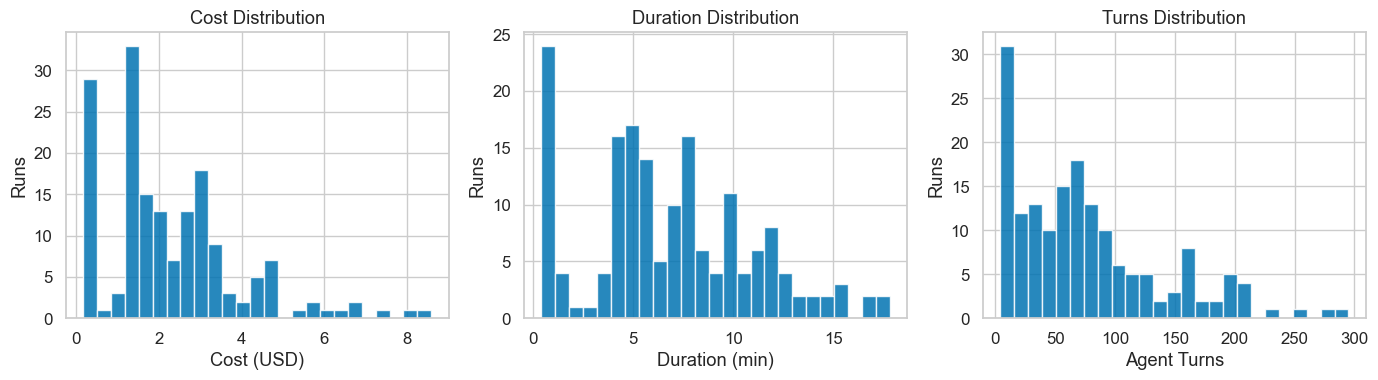

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["total_cost_usd"], bins=25, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Cost (USD)")
axes[0].set_ylabel("Runs")
axes[0].set_title("Cost Distribution")

axes[1].hist(df["wall_clock_secs"] / 60, bins=25, edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Duration (min)")
axes[1].set_ylabel("Runs")
axes[1].set_title("Duration Distribution")

axes[2].hist(df["total_turns"], bins=25, edgecolor="white", alpha=0.85)
axes[2].set_xlabel("Agent Turns")
axes[2].set_ylabel("Runs")
axes[2].set_title("Turns Distribution")

plt.tight_layout()
plt.show()

## 2. Complexity vs Cost

**Hypothesis:** Complex classes cost more to synthesize.

We compare cost distributions across complexity levels using boxplots and a Kruskal-Wallis test (non-parametric, no normality assumption). If significant, Dunn's post-hoc test identifies which pairs differ.

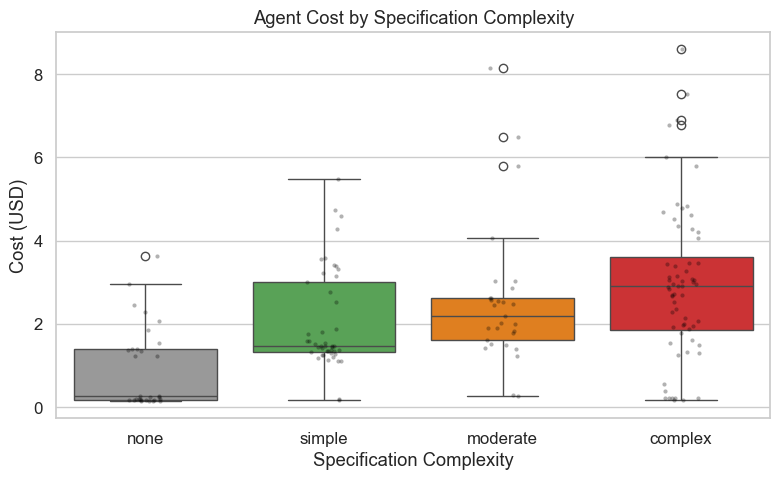


--- Cost by complexity ---
Kruskal-Wallis H=39.19, p=1.581e-08, epsilon²=0.235 (large)

Dunn's post-hoc (Bonferroni-adjusted p-values):


,none,simple,moderate,complex
none,1.0000,0.0052,0.0001,0.0000
simple,0.0052,1.0000,0.9214,0.0226
moderate,0.0001,0.9214,1.0000,1.0000
complex,0.0000,0.0226,1.0000,1.0000


(np.float64(39.19185678011934),
 np.float64(1.580591586007512e-08),
 np.float64(0.2346817771264631),
                   none    simple  moderate       complex
 none      1.000000e+00  0.005193  0.000094  6.544948e-09
 simple    5.193325e-03  1.000000  0.921378  2.259548e-02
 moderate  9.371961e-05  0.921378  1.000000  1.000000e+00
 complex   6.544948e-09  0.022595  1.000000  1.000000e+00)

In [4]:
def kruskal_and_dunn(df, metric, group="complexity", order=COMPLEXITY_ORDER):
    """Run Kruskal-Wallis with effect size and, if significant, Dunn's post-hoc test."""
    groups = [g[metric].values for _, g in df.groupby(group, observed=True)]
    h_stat, p_val = stats.kruskal(*groups)
    n = len(df)
    # Epsilon-squared effect size: H / ((n^2 - 1) / (n + 1))
    eps_sq = h_stat / ((n**2 - 1) / (n + 1))
    size_label = "large" if eps_sq >= 0.14 else "medium" if eps_sq >= 0.06 else "small"
    print(f"Kruskal-Wallis H={h_stat:.2f}, p={p_val:.4g}, epsilon²={eps_sq:.3f} ({size_label})")
    if p_val < 0.05:
        dunn = sp.posthoc_dunn(df, val_col=metric, group_col=group, p_adjust="bonferroni")
        dunn = dunn.reindex(index=order, columns=order)
        print("\nDunn's post-hoc (Bonferroni-adjusted p-values):")
        display(dunn.round(4))
        return h_stat, p_val, eps_sq, dunn
    return h_stat, p_val, eps_sq, None

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="complexity", y="total_cost_usd", order=COMPLEXITY_ORDER,
            palette=COMPLEXITY_COLORS, ax=ax, showfliers=True)
sns.stripplot(data=df, x="complexity", y="total_cost_usd", order=COMPLEXITY_ORDER,
              color="black", alpha=0.3, size=3, ax=ax, jitter=True)
ax.set_xlabel("Specification Complexity")
ax.set_ylabel("Cost (USD)")
ax.set_title("Agent Cost by Specification Complexity")
plt.tight_layout()
plt.show()

print("\n--- Cost by complexity ---")
kruskal_and_dunn(df, "total_cost_usd")

## 3. Complexity vs Duration

Same analysis for wall-clock time.

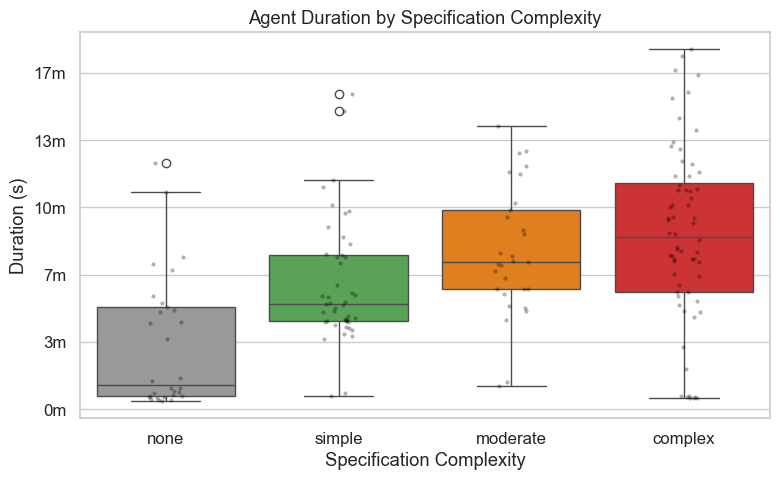

--- Duration by complexity ---
Kruskal-Wallis H=39.80, p=1.172e-08, epsilon²=0.238 (large)

Dunn's post-hoc (Bonferroni-adjusted p-values):


,none,simple,moderate,complex
none,1.0000,0.0246,0.0000,0.0000
simple,0.0246,1.0000,0.1983,0.0064
moderate,0.0000,0.1983,1.0000,1.0000
complex,0.0000,0.0064,1.0000,1.0000


(np.float64(39.804647582652365),
 np.float64(1.1720980119672211e-08),
 np.float64(0.2383511831296549),
                   none    simple  moderate       complex
 none      1.000000e+00  0.024582  0.000033  1.742886e-08
 simple    2.458226e-02  1.000000  0.198292  6.352162e-03
 moderate  3.261101e-05  0.198292  1.000000  1.000000e+00
 complex   1.742886e-08  0.006352  1.000000  1.000000e+00)

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="complexity", y="wall_clock_secs", order=COMPLEXITY_ORDER,
            palette=COMPLEXITY_COLORS, ax=ax)
sns.stripplot(data=df, x="complexity", y="wall_clock_secs", order=COMPLEXITY_ORDER,
              color="black", alpha=0.3, size=3, ax=ax, jitter=True)
ax.set_xlabel("Specification Complexity")
ax.set_ylabel("Duration (s)")
ax.set_title("Agent Duration by Specification Complexity")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f}m"))
plt.tight_layout()
plt.show()

print("--- Duration by complexity ---")
kruskal_and_dunn(df, "wall_clock_secs")

## 4. Complexity vs Turns and MCP Tool Usage

**Hypothesis:** Complex classes require more agent turns and more MCP tool invocations (validate_dfa, verify_liquidjava, etc.).

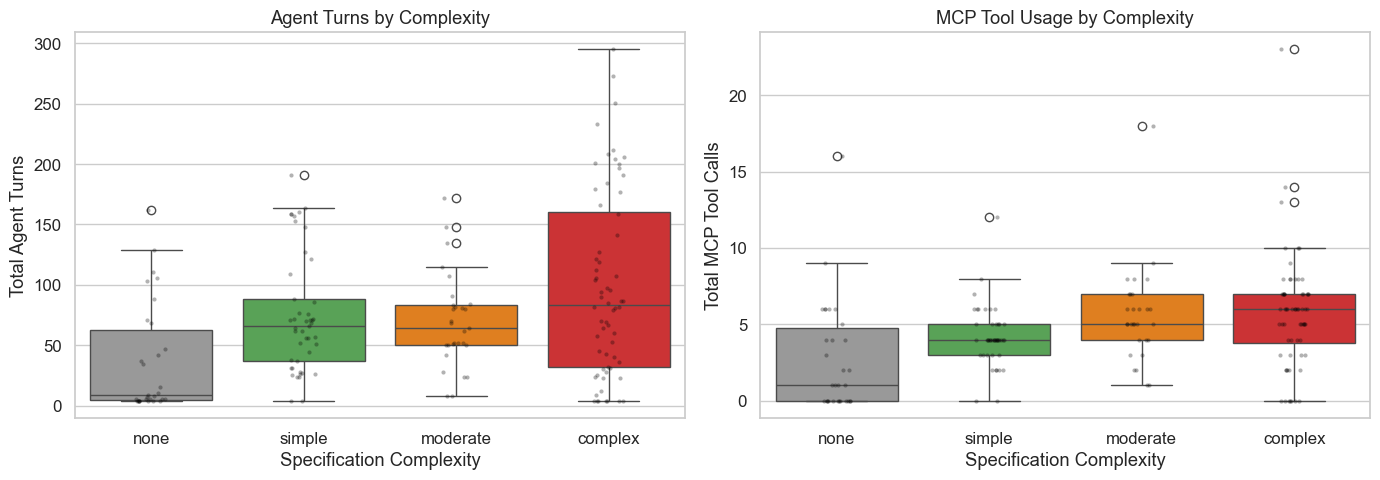

--- Total turns by complexity ---
Kruskal-Wallis H=20.18, p=0.0001561, epsilon²=0.121 (medium)

Dunn's post-hoc (Bonferroni-adjusted p-values):


,none,simple,moderate,complex
none,1.0000,0.0068,0.0267,0.0
simple,0.0068,1.0000,1.0000,1.0
moderate,0.0267,1.0000,1.0000,1.0
complex,0.0000,1.0000,1.0000,1.0



--- MCP calls by complexity ---
Kruskal-Wallis H=24.62, p=1.855e-05, epsilon²=0.147 (large)

Dunn's post-hoc (Bonferroni-adjusted p-values):


,none,simple,moderate,complex
none,1.0000,0.2625,0.0013,0.0000
simple,0.2625,1.0000,0.2387,0.0426
moderate,0.0013,0.2387,1.0000,1.0000
complex,0.0000,0.0426,1.0000,1.0000


(np.float64(24.61874955274944),
 np.float64(1.8550383535436294e-05),
 np.float64(0.1474176619925116),
               none    simple  moderate   complex
 none      1.000000  0.262478  0.001268  0.000038
 simple    0.262478  1.000000  0.238717  0.042619
 moderate  0.001268  0.238717  1.000000  1.000000
 complex   0.000038  0.042619  1.000000  1.000000)

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="complexity", y="total_turns", order=COMPLEXITY_ORDER,
            palette=COMPLEXITY_COLORS, ax=axes[0])
sns.stripplot(data=df, x="complexity", y="total_turns", order=COMPLEXITY_ORDER,
              color="black", alpha=0.3, size=3, ax=axes[0], jitter=True)
axes[0].set_xlabel("Specification Complexity")
axes[0].set_ylabel("Total Agent Turns")
axes[0].set_title("Agent Turns by Complexity")

sns.boxplot(data=df, x="complexity", y="total_mcp_calls", order=COMPLEXITY_ORDER,
            palette=COMPLEXITY_COLORS, ax=axes[1])
sns.stripplot(data=df, x="complexity", y="total_mcp_calls", order=COMPLEXITY_ORDER,
              color="black", alpha=0.3, size=3, ax=axes[1], jitter=True)
axes[1].set_xlabel("Specification Complexity")
axes[1].set_ylabel("Total MCP Tool Calls")
axes[1].set_title("MCP Tool Usage by Complexity")

plt.tight_layout()
plt.show()

print("--- Total turns by complexity ---")
kruskal_and_dunn(df, "total_turns")
print("\n--- MCP calls by complexity ---")
kruskal_and_dunn(df, "total_mcp_calls")

## 5. Summary Table by Complexity Level

Mean values for key metrics, grouped by complexity.

In [7]:
group_stats = df.groupby("complexity", observed=True).agg(
    n_classes=("class_name", "nunique"),
    n_runs=("class_name", "size"),
    cost_mean=("total_cost_usd", "mean"),
    cost_std=("total_cost_usd", "std"),
    duration_mean=("wall_clock_secs", "mean"),
    duration_std=("wall_clock_secs", "std"),
    turns_mean=("total_turns", "mean"),
    turns_std=("total_turns", "std"),
    mcp_mean=("total_mcp_calls", "mean"),
    mcp_std=("total_mcp_calls", "std"),
    tool_calls_mean=("total_tool_calls", "mean"),
    errors_mean=("total_tool_errors", "mean"),
).round(2)

group_stats.index.name = "Complexity"
group_stats.columns = [
    "Classes", "Runs",
    "Cost Mean", "Cost Std",
    "Duration Mean (s)", "Duration Std",
    "Turns Mean", "Turns Std",
    "MCP Mean", "MCP Std",
    "Tool Calls Mean", "Errors Mean",
]
group_stats

,Classes,Runs,Cost Mean,Cost Std,Duration Mean (s),Duration Std,Turns Mean,Turns Std,MCP Mean,MCP Std,Tool Calls Mean,Errors Mean
Complexity,,,,,,,,,,,,
none,6,30,0.94,0.99,191.72,196.27,36.80,45.90,2.77,3.63,32.23,0.30
simple,9,45,2.05,1.21,371.48,184.45,74.78,48.78,4.22,1.99,67.51,1.04
moderate,7,29,2.56,1.70,466.37,193.27,69.41,38.95,5.55,3.17,61.31,0.97
complex,13,64,2.93,1.85,515.15,266.73,98.48,76.86,5.66,3.73,91.45,1.20


## 6. "None" Baseline — Agent Effort Without Typestate

Classes with no typestate protocol (PopupMenu, Clipboard, etc.) serve as a baseline. The agent still expends effort analyzing the class before concluding no specification is needed.

In [8]:
none_df = df[df["complexity"] == "none"]
rest_df = df[df["complexity"] != "none"]

print(f"'None' classes: {none_df['class_name'].nunique()} classes, {len(none_df)} runs")
print(f"Classes with typestate: {rest_df['class_name'].nunique()} classes, {len(rest_df)} runs")
print()

for metric, label in [("total_cost_usd", "Cost (USD)"), ("wall_clock_secs", "Duration (s)"), ("total_turns", "Turns")]:
    u_stat, p_val = stats.mannwhitneyu(none_df[metric], rest_df[metric], alternative="less")
    # Rank-biserial correlation as effect size: r = 1 - 2U/(n1*n2)
    n1, n2 = len(none_df), len(rest_df)
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    size_label = "large" if abs(r_rb) >= 0.5 else "medium" if abs(r_rb) >= 0.3 else "small"
    print(f"{label}: none median={none_df[metric].median():.2f}, "
          f"rest median={rest_df[metric].median():.2f}, "
          f"U p={p_val:.4g}, r={r_rb:.2f} ({size_label})")

'None' classes: 6 classes, 30 runs
Classes with typestate: 29 classes, 138 runs

Cost (USD): none median=0.26, rest median=2.24, U p=1.45e-08, r=0.65 (large)
Duration (s): none median=73.64, rest median=444.19, U p=4.331e-08, r=0.62 (large)
Turns: none median=8.50, rest median=70.00, U p=9.233e-06, r=0.50 (medium)


## 7. Per-Class Variability (Reproducibility)

Coefficient of Variation (CV = std/mean) for cost across the 5 runs of each class. Higher CV means less reproducible. Are complex classes noisier?

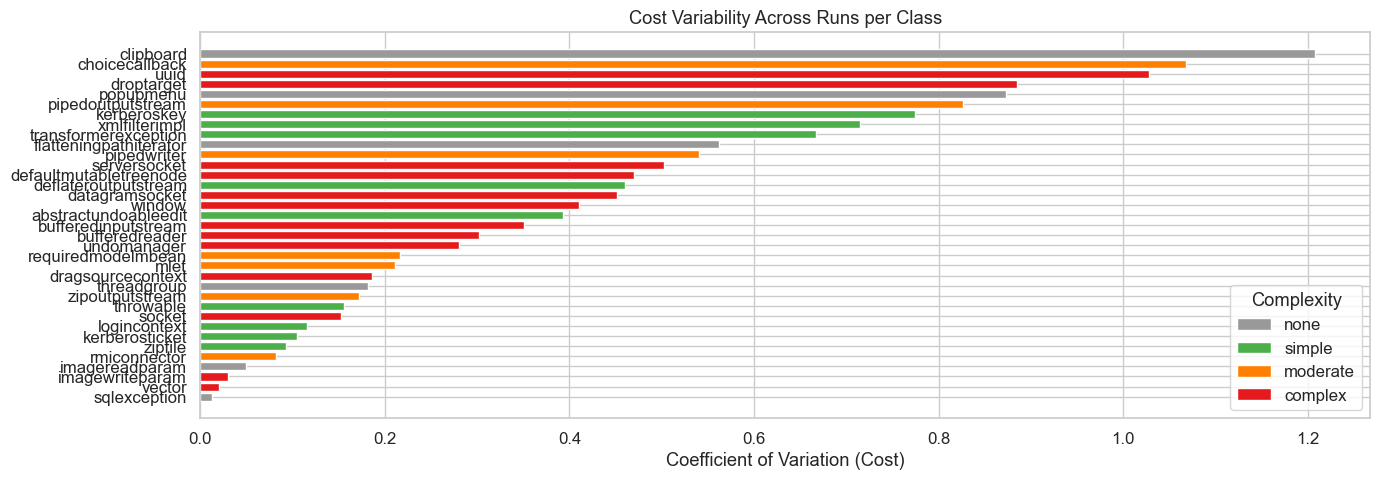

Median CV by complexity:
complexity
none        0.372
simple      0.393
moderate    0.216
complex     0.350
Name: cv, dtype: float64


In [9]:
cv_df = df.groupby(["class_name", "complexity"], observed=True)["total_cost_usd"].agg(["mean", "std"]).reset_index()
cv_df["cv"] = cv_df["std"] / cv_df["mean"]
cv_df = cv_df.sort_values("cv", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(
    cv_df["class_name"],
    cv_df["cv"],
    color=[COMPLEXITY_COLORS[c] for c in cv_df["complexity"]],
    edgecolor="white",
)
ax.set_xlabel("Coefficient of Variation (Cost)")
ax.set_title("Cost Variability Across Runs per Class")
ax.invert_yaxis()

legend_elements = [Patch(facecolor=COMPLEXITY_COLORS[c], label=c) for c in COMPLEXITY_ORDER]
ax.legend(handles=legend_elements, title="Complexity", loc="lower right")
plt.tight_layout()
plt.show()

# CV by complexity group
print("Median CV by complexity:")
print(cv_df.groupby("complexity", observed=True)["cv"].median().reindex(COMPLEXITY_ORDER).round(3))

## 8. Cost Drivers — Correlations

What predicts cost? We compute Spearman correlations on **class-level means** (n=35) to avoid inflated significance from non-independent runs within the same class.

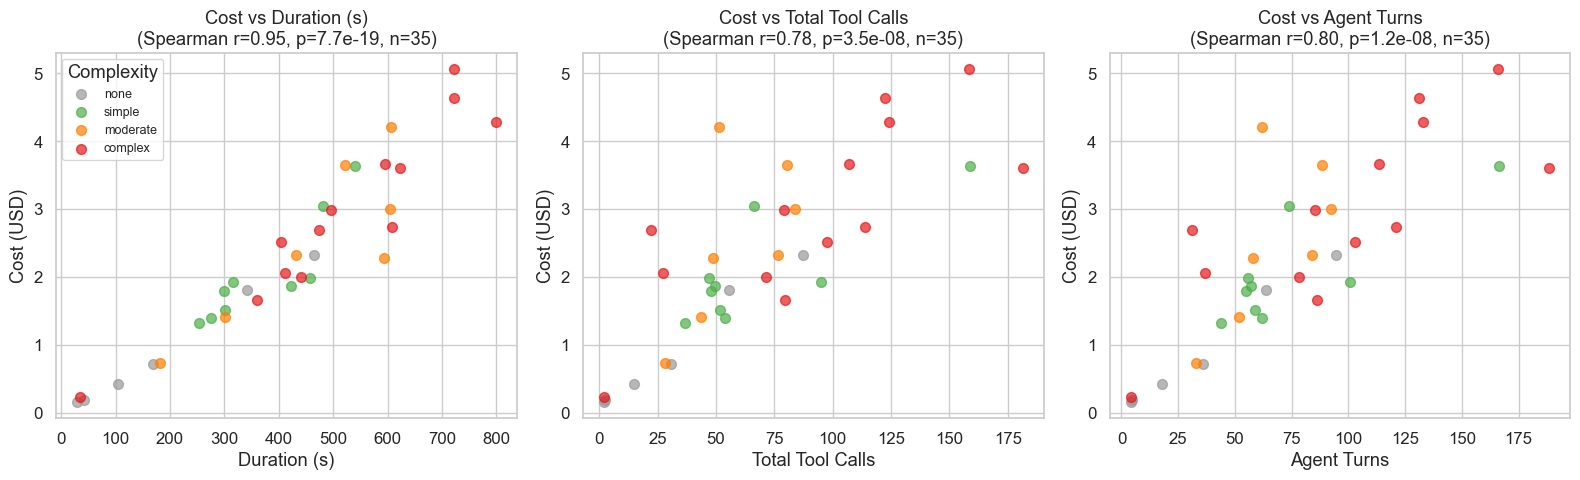

In [10]:
# Aggregate to class-level means for correlation (avoids non-independence)
class_means = df.groupby(["class_name", "complexity"], observed=True).agg(
    cost=("total_cost_usd", "mean"),
    duration=("wall_clock_secs", "mean"),
    tool_calls=("total_tool_calls", "mean"),
    turns=("total_turns", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [
    ("duration", "Duration (s)"),
    ("tool_calls", "Total Tool Calls"),
    ("turns", "Agent Turns"),
]

for ax, (col, label) in zip(axes, pairs):
    for comp_level in COMPLEXITY_ORDER:
        subset = class_means[class_means["complexity"] == comp_level]
        ax.scatter(subset[col], subset["cost"], label=comp_level,
                   color=COMPLEXITY_COLORS[comp_level], alpha=0.7, s=50)
    r, p = stats.spearmanr(class_means[col], class_means["cost"])
    ax.set_xlabel(label)
    ax.set_ylabel("Cost (USD)")
    ax.set_title(f"Cost vs {label}\n(Spearman r={r:.2f}, p={p:.2g}, n=35)")

axes[0].legend(title="Complexity", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Per-Class Cost Ranking

Mean cost per class (averaged over 5 runs), sorted by cost. Highlights which classes are most expensive.

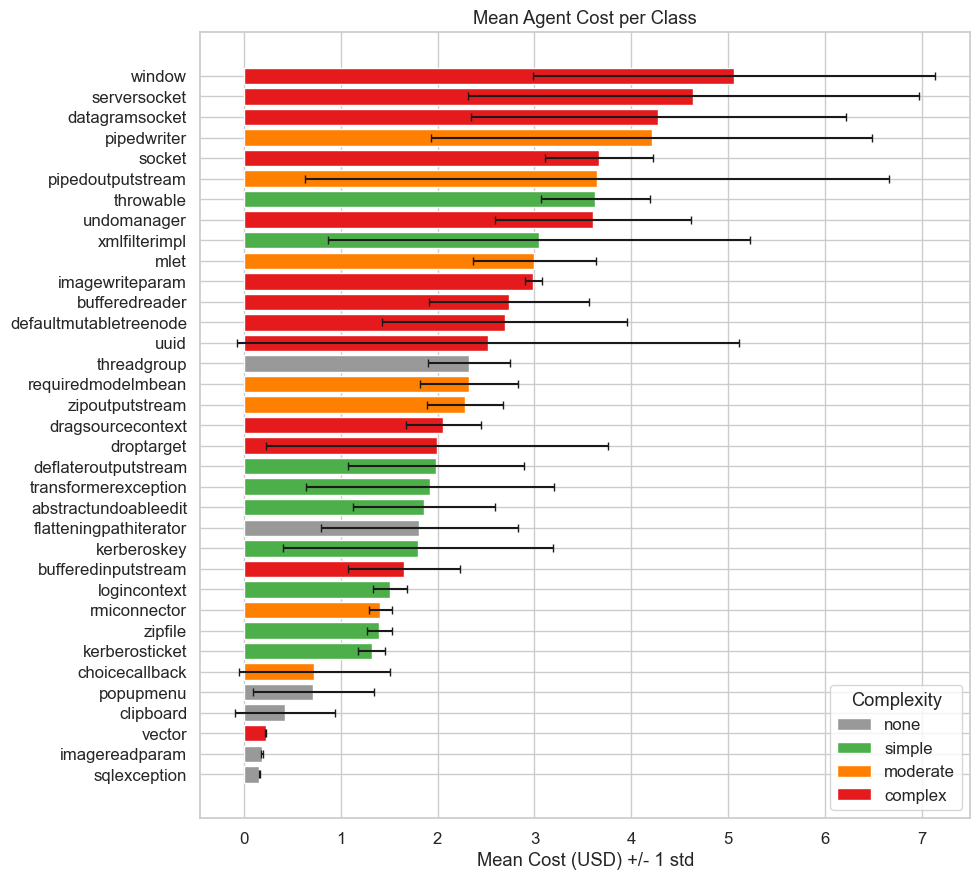

In [11]:
class_cost = df.groupby(["class_name", "complexity"], observed=True).agg(
    cost_mean=("total_cost_usd", "mean"),
    cost_std=("total_cost_usd", "std"),
).reset_index().sort_values("cost_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    class_cost["class_name"],
    class_cost["cost_mean"],
    xerr=class_cost["cost_std"],
    color=[COMPLEXITY_COLORS[c] for c in class_cost["complexity"]],
    edgecolor="white",
    capsize=3,
)
ax.set_xlabel("Mean Cost (USD) +/- 1 std")
ax.set_title("Mean Agent Cost per Class")

legend_elements = [Patch(facecolor=COMPLEXITY_COLORS[c], label=c) for c in COMPLEXITY_ORDER]
ax.legend(handles=legend_elements, title="Complexity", loc="lower right")
plt.tight_layout()
plt.show()

## 10. Tool Usage Breakdown by Complexity

Which tools does the agent use more when facing harder specifications?

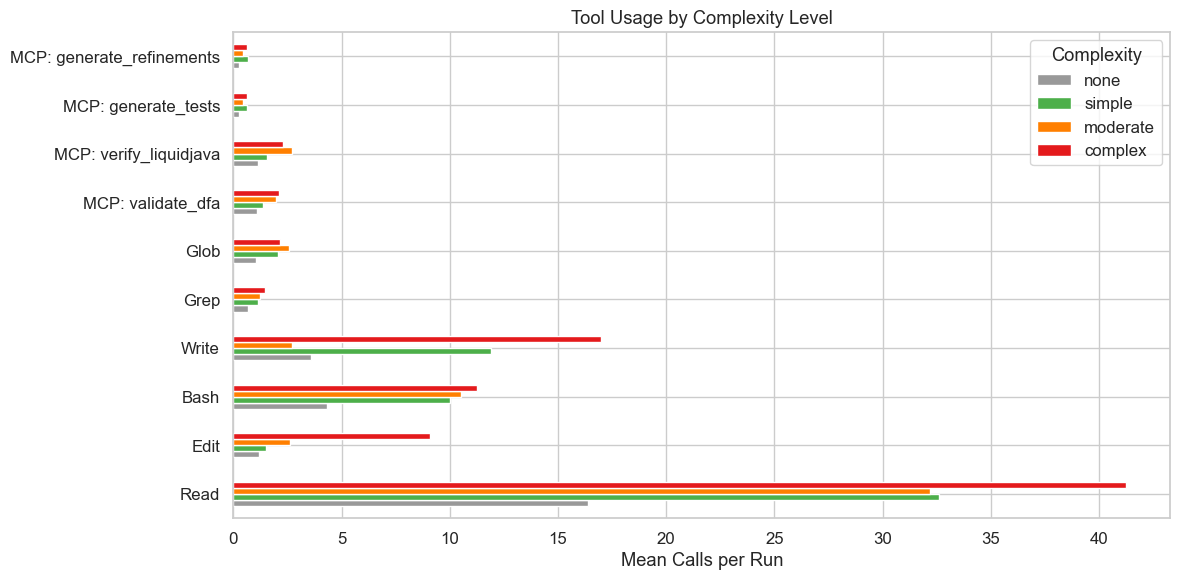

,Read,Edit,Bash,Write,Grep,Glob,MCP: validate_dfa,MCP: verify_liquidjava,MCP: generate_tests,MCP: generate_refinements
complexity,,,,,,,,,,
none,16.4,1.2,4.3,3.6,0.7,1.1,1.1,1.1,0.3,0.3
simple,32.6,1.5,10.0,11.9,1.2,2.1,1.4,1.5,0.6,0.7
moderate,32.2,2.6,10.5,2.7,1.2,2.6,2.0,2.7,0.4,0.4
complex,41.2,9.1,11.3,17.0,1.5,2.1,2.1,2.3,0.6,0.6


In [12]:
tool_cols = ["tool_Read", "tool_Edit", "tool_Bash", "tool_Write", "tool_Grep", "tool_Glob"]
mcp_detail_cols = ["tool_mcp_validate_dfa", "tool_mcp_verify_liquidjava", "tool_mcp_generate_tests", "tool_mcp_generate_refinements"]
all_tool_cols = tool_cols + mcp_detail_cols

# Mean tool usage per complexity level
tool_by_complexity = df.groupby("complexity", observed=True)[all_tool_cols].mean()
tool_by_complexity.columns = [c.replace("tool_", "").replace("mcp_", "MCP: ") for c in all_tool_cols]

fig, ax = plt.subplots(figsize=(12, 6))
tool_by_complexity.T.plot(kind="barh", ax=ax, color=[COMPLEXITY_COLORS[c] for c in COMPLEXITY_ORDER])
ax.set_xlabel("Mean Calls per Run")
ax.set_title("Tool Usage by Complexity Level")
ax.legend(title="Complexity")
plt.tight_layout()
plt.show()

tool_by_complexity.round(1)

## 11. Reliability — Intraclass Correlation (ICC)

How much of the variance in cost is explained by which class is being analyzed (between-class) vs. run-to-run noise (within-class)? A high ICC means the agent's effort is primarily determined by class identity, not random variation.

In [13]:
# ICC(1,1) via one-way random effects ANOVA decomposition
def compute_icc(df, metric, group="class_name"):
    """Compute ICC(1,1) from one-way ANOVA components."""
    groups = [g[metric].values for _, g in df.groupby(group)]
    k = len(groups[0])  # runs per class (assumed equal)
    n = len(groups)      # number of classes

    grand_mean = df[metric].mean()
    ms_between = k * sum(len(g) * (g.mean() - grand_mean)**2 for g in groups) / (n - 1)
    ms_within = sum(((g - g.mean())**2).sum() for g in groups) / (n * (k - 1))

    icc = (ms_between - ms_within) / (ms_between + (k - 1) * ms_within)
    return icc, ms_between, ms_within

# Only use classes with exactly the same number of runs for clean ICC
runs_per_class = df.groupby("class_name").size()
k_mode = runs_per_class.mode().iloc[0]
balanced_classes = runs_per_class[runs_per_class == k_mode].index
df_balanced = df[df["class_name"].isin(balanced_classes)]

print(f"Computing ICC on {len(balanced_classes)} classes with {k_mode} runs each ({len(df_balanced)} total runs)")
print()

for metric, label in [("total_cost_usd", "Cost"), ("wall_clock_secs", "Duration"), ("total_turns", "Turns")]:
    icc, msb, msw = compute_icc(df_balanced, metric)
    reliability = "excellent" if icc >= 0.75 else "good" if icc >= 0.6 else "moderate" if icc >= 0.4 else "poor"
    print(f"{label}: ICC(1,1) = {icc:.3f} ({reliability})"
          f"  [MS_between={msb:.1f}, MS_within={msw:.1f}]")

Computing ICC on 30 classes with 5 runs each (150 total runs)

Cost: ICC(1,1) = 0.856 (excellent)  [MS_between=40.9, MS_within=1.3]
Duration: ICC(1,1) = 0.870 (excellent)  [MS_between=1036031.8, MS_within=30094.9]
Turns: ICC(1,1) = 0.820 (excellent)  [MS_between=58796.0, MS_within=2468.4]


## 12. Key Findings

In [14]:
from IPython.display import Markdown

total_cost = df["total_cost_usd"].sum()
mean_cost = df["total_cost_usd"].mean()
median_cost = df["total_cost_usd"].median()
mean_dur = df["wall_clock_secs"].mean()

g = df.groupby("complexity", observed=True)
none_med = g["total_cost_usd"].median().loc["none"]
complex_med = g["total_cost_usd"].median().loc["complex"]
ratio = complex_med / none_med if none_med > 0 else float("inf")

median_cv = cv_df["cv"].median()
most_expensive = class_cost.iloc[-1]
cheapest = class_cost.iloc[0]

# ICC values
icc_cost, _, _ = compute_icc(df_balanced, "total_cost_usd")

findings = f"""
**Summary of {len(df)} valid runs ({len(df_raw) - len(df)} excluded as failed) across {df['class_name'].nunique()} classes:**

1. **Overall effort:** Median cost per run is **${median_cost:.2f}** (mean ${mean_cost:.2f}, total ${total_cost:.0f}).
   Mean duration is **{mean_dur/60:.1f} minutes**.

2. **Complexity drives cost:** Complex classes cost **{ratio:.1f}x more** than "none" classes
   (median ${complex_med:.2f} vs ${none_med:.2f}). Kruskal-Wallis is highly significant with a
   large effect size (see Section 2).

3. **Most expensive class:** `{most_expensive['class_name']}` ({most_expensive['complexity']}) at
   ${most_expensive['cost_mean']:.2f} +/- ${most_expensive['cost_std']:.2f} per run.

4. **Cheapest class:** `{cheapest['class_name']}` ({cheapest['complexity']}) at
   ${cheapest['cost_mean']:.2f} +/- ${cheapest['cost_std']:.2f} per run.

5. **Reliability:** ICC(1,1) for cost is **{icc_cost:.2f}** — class identity explains most of the
   variance, confirming that cost is driven by the class, not random run-to-run variation.

6. **Reproducibility:** Median CV of cost is **{median_cv:.2f}** across classes.

7. **Baseline cost (no typestate):** Even "none" classes cost ~${none_med:.2f} (median) per run —
   the agent still analyzes the class before determining no specification is needed.

8. **Tool patterns:** Complex classes use substantially more Read, Edit, and MCP tool calls
   than simpler classes (see Section 10).
"""
Markdown(findings)


**Summary of 168 valid runs (7 excluded as failed) across 35 classes:**

1. **Overall effort:** Median cost per run is **$1.91** (mean $2.27, total $382).
   Mean duration is **6.8 minutes**.

2. **Complexity drives cost:** Complex classes cost **11.0x more** than "none" classes
   (median $2.90 vs $0.26). Kruskal-Wallis is highly significant with a
   large effect size (see Section 2).

3. **Most expensive class:** `window` (complex) at
   $5.06 +/- $2.08 per run.

4. **Cheapest class:** `sqlexception` (none) at
   $0.16 +/- $0.00 per run.

5. **Reliability:** ICC(1,1) for cost is **0.86** — class identity explains most of the
   variance, confirming that cost is driven by the class, not random run-to-run variation.

6. **Reproducibility:** Median CV of cost is **0.35** across classes.

7. **Baseline cost (no typestate):** Even "none" classes cost ~$0.26 (median) per run —
   the agent still analyzes the class before determining no specification is needed.

8. **Tool patterns:** Complex classes use substantially more Read, Edit, and MCP tool calls
   than simpler classes (see Section 10).
